# MLSS Workshop for Efficient Inference 

## Goals
- Learn how to use vLLM for our experimental needs
- How do we get out optimal performance?
- Learn some advanced techniques for maximum speed-up


## Setup

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.benchmark as benchmark
from vllm import LLM, SamplingParams

assert torch.cuda.is_available(), "This notebook needs a GPU."

# point somewhere with a few GB free BEFORE the download cell runs
# os.environ["HF_HOME"] = "/path/with/space/hf_home"

# My node didn't have the corresponding toolkit installed
os.environ.setdefault("VLLM_USE_FLASHINFER_SAMPLER", "0")
MODEL = "Qwen/Qwen3-4B"


/lustre/fast/fast/aconzelmann/vllm-tutorial/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# !hf download {MODEL}
# !pip install vllm torch matplotlib numpy huggingface_hub

#### Plotting

In [3]:
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#23373b", "#5c6b70", "#dfe3e4"
SERIES = (BLUE, ORANGE, AQUA)

# Marker style shared by every line plot: filled dot with a white halo, so
# overlapping points stay readable.
DOT = dict(marker="o", ms=8, markeredgecolor="white", markeredgewidth=2)


def style_axes(ax, *, title=None, xlabel=None, ylabel=None, legend=None):
    """Apply the tutorial's axis style: light grid, no box, muted ticks."""
    if title:
        ax.set_title(title, color=INK, fontsize=12, loc="left", pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK)
    ax.grid(True, which="major", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED)
    if legend:
        ax.legend(frameon=False, loc=legend, labelcolor=INK)
    return ax


def plot_roofline(
    tokens,
    tflops,
    *,
    peak_tflops,
    bandwidth_tbs,
    achieved_tflops=None,
    annotations=(),
    device=None,
    figsize=(8, 4.8),
):
    """Measured (tokens, TFLOP/s) points against the theoretical roof.

    The x axis is tokens per forward pass. Counting only the weight read, the
    intensity of an (m, d) x (d, d) matmul is 2md^2 / 2d^2 = m FLOP/byte, so
    tokens and intensity are the same axis and the ridge is a batch size:
    how many tokens must be in flight before the tensor cores stop idling.
    Both `peak_tflops` and `bandwidth_tbs` are datasheet numbers, so the roof
    and ridge drawn here are the theoretical ones. `achieved_tflops` optionally
    marks the best throughput actually reached. Each annotation is
    `(label, x, y)`, with optional `xytext` and horizontal alignment appended
    when the default placement collides with something.
    """
    mm = np.logspace(0, 4.7, 2000)
    roof = np.minimum(peak_tflops, mm * bandwidth_tbs)
    ridge_m = peak_tflops / bandwidth_tbs

    fig, ax = plt.subplots(figsize=figsize)
    ax.fill_betweenx(
        [1e-2, peak_tflops * 1.6], 0.8, ridge_m, color=GRID, alpha=0.35, lw=0
    )
    ax.text(0.95, 1.5e-2, "memory-bound", color=MUTED, fontsize=9)
    ax.text(ridge_m * 1.35, 1.5e-2, "compute-bound", color=MUTED, fontsize=9)

    ax.plot(
        mm,
        roof,
        color=BLUE,
        lw=2,
        zorder=3,
        label=f"Roofline, spec  ({peak_tflops:.0f} TFLOP/s, "
        f"{bandwidth_tbs * 1e3:.0f} GB/s)",
    )
    if achieved_tflops:
        ax.axhline(
            achieved_tflops,
            color=AQUA,
            lw=1.2,
            ls=":",
            zorder=2,
            label=f"Best achieved  ({achieved_tflops:.0f} TFLOP/s, "
            f"{achieved_tflops / peak_tflops:.0%} of peak)",
        )
    ax.plot(
        tokens,
        tflops,
        "o",
        ms=8,
        color=ORANGE,
        zorder=5,
        markeredgecolor="white",
        markeredgewidth=2,
        label="Measured  $(m, d)\\times(d, d)$",
    )

    ax.axvline(ridge_m, color=MUTED, lw=1, ls="--", zorder=2)
    ax.text(
        ridge_m * 1.2,
        peak_tflops * 1.22,
        f"ridge = {ridge_m:.0f} tokens",
        color=MUTED,
        fontsize=9,
        ha="left",
    )

    for label, x, y, *rest in annotations:
        xytext, ha = (rest + [None, "left"])[:2] if rest else (None, "left")
        ax.annotate(
            f"{label}\n{y:.1f} TFLOP/s  ({y / peak_tflops:.1%} of peak)",
            xy=(x, y),
            xytext=xytext or (x * 1.6, y * 0.22),
            color=INK,
            fontsize=9,
            ha=ha,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1),
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.8, 3e4)
    ax.set_ylim(1e-2, peak_tflops * 1.6)
    style_axes(
        ax,
        title=f"Roofline on {device}" if device else "Roofline",
        xlabel="Tokens per forward pass  $m$",
        ylabel="Achieved throughput  [TFLOP/s]",
        legend="upper left",
    )
    fig.tight_layout()
    return fig, ax


def plot_scaling(
    x,
    series,
    *,
    xlabel,
    ylabel,
    title,
    ideal_from=None,
    legend="lower right",
    figsize=(8, 4.6),
):
    """Log-log plot of one or more series over a power-of-two x axis.

    `series` maps label -> values, drawn in palette order. `ideal_from` names the
    series to anchor a dashed linear-scaling reference on, at its first point.
    """
    fig, ax = plt.subplots(figsize=figsize)
    for (label, values), color in zip(series.items(), SERIES):
        ax.plot(x, values, "-", color=color, lw=2, label=label, **DOT)

    if ideal_from:
        first = series[ideal_from][0]
        ax.plot(
            x,
            [first * xi / x[0] for xi in x],
            ls="--",
            lw=1,
            color=MUTED,
            label=f"{ideal_from}, linear scaling",
        )

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(x)
    style_axes(ax, title=title, xlabel=xlabel, ylabel=ylabel, legend=legend)
    fig.tight_layout()
    return fig, ax


## The roofline: what limits us

Every kernel is capped by whichever resource runs out first, compute or memory bandwidth:

$$\text{Achieved FLOP/s} = \min\big(\text{Peak Compute},\ \text{AI} \times \text{Bandwidth}\big),
\qquad \text{AI} = \frac{\text{FLOPs}}{\text{bytes moved from HBM}}$$

Recall the two stages from the slides. For a weight matrix $W \in \mathbb{R}^{d \times d}$:

- **Prefill:** all $m$ prompt tokens go through at once, e.g. $Q = XW_Q$ is a *matrix-matrix* product $(m, d) \times (d, d)$.
- **Decode:** one token at a time, e.g. the projection $q = xW_Q$ is $(1, d) \times (d, d)$.

In bf16 the weights are $2d^2$ bytes and the matmul is $2md^2$ FLOPs, so

$$\text{AI} = \frac{2md^2}{2d^2} \approx m$$

meaning the arithmetic intensity is equal to the number of tokens we push through. **Caveat**: This only holds in the regime $m \ll d$, 
as otherwise, we also need to take care of moving $X$ to and from the GPU memory (whose size scales with $m$).

Since tokens and intensity have the same axis, the ridge point is readable as a **batch size**: 
how many tokens must be in flight before the tensor cores stop idling.

In [4]:
dev = torch.device("cuda")
dtype = torch.bfloat16
d = 2560

W = torch.randn(d, d, device=dev, dtype=dtype)
esz = W.element_size()
bytes_W = W.numel() * esz


def flops(m):
    return 2 * m * d**2


MS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

print(f"{'m':>9} | {'latency':>10} | {'TFLOP/s':>9}")
print("-" * 42)

## Benchmarking Matrix Multiplication
results = {}
for m in MS:
    X = torch.randn(m, d, device=dev, dtype=dtype)
    t = benchmark.Timer(
        stmt="X @ W",
        globals={"X": X, "W": W},
        label="gemm",
        sub_label=f"m={m}",
        description="X @ W",
    ).blocked_autorange(min_run_time=1.0)
    latency = t.median  # seconds per call
    results[m] = latency
    del X
    print(f"{m:9d} | {latency * 1e6:8.1f} us | {flops(m) / latency / 1e12:9.2f} ")

# Benchmarking Bandwidth using a large device copy
nbytes = 512 * 1024**2
src = torch.empty(nbytes, dtype=torch.uint8, device=dev)
dst = torch.empty_like(src)
t_copy = benchmark.Timer(
    stmt="dst.copy_(src)",
    globals={"src": src, "dst": dst},
    label="copy",
    description="dst.copy_(src)",
).blocked_autorange(min_run_time=1.0)
BW_TBS = 2 * nbytes / t_copy.median / 1e12  # read + write
del src, dst

tflops = {m: flops(m) / results[m] / 1e12 for m in MS}
PEAK_TFLOPS = max(tflops.values())

# https://www.techpowerup.com/gpu-specs/a100-sxm4-40-gb.c3506
GPU_PEAK_TFLOPS_OPT = 312
GPU_BW_TBS_OPT = 1.555
RIDGE_OPT = GPU_PEAK_TFLOPS_OPT / GPU_BW_TBS_OPT

print(
    f"\nstreaming bandwidth : {BW_TBS * 1e3:8.0f} GB/s   (copy of {nbytes // 1024**2} MB, "
    f"{BW_TBS / GPU_BW_TBS_OPT:.0%} of spec)"
)
print(
    f"peak matmul         : {PEAK_TFLOPS:8.1f} TFLOP/s ({PEAK_TFLOPS / GPU_PEAK_TFLOPS_OPT:.0%} of spec)"
)
print(f"spec compute        : {GPU_PEAK_TFLOPS_OPT:8.0f} TFLOP/s")
print(f"theoretical ridge   : {RIDGE_OPT:8.0f} FLOP/byte ")


        m |    latency |   TFLOP/s
------------------------------------------
        1 |     35.2 us |      0.37 
        2 |     18.3 us |      1.43 
        4 |     14.0 us |      3.76 
        8 |     17.5 us |      6.00 
       16 |     17.5 us |     12.00 
       32 |     14.0 us |     29.92 
       64 |     17.5 us |     47.91 
      128 |     18.1 us |     92.54 
      256 |     25.2 us |    133.37 
      512 |     39.8 us |    168.61 
     1024 |     73.9 us |    181.55 
     2048 |    147.5 us |    182.04 
     4096 |    247.4 us |    217.00 
     8192 |    493.3 us |    217.69 
    16384 |    982.5 us |    218.58 

streaming bandwidth :     1374 GB/s   (copy of 512 MB, 88% of spec)
peak matmul         :    218.6 TFLOP/s (70% of spec)
spec compute        :      312 TFLOP/s
theoretical ridge   :      201 FLOP/byte 


At small $m$ the **latency barely moves** — 128 tokens cost about what
1 token costs, because the kernel is just waiting on the $2d^2$-byte weight read. At large $m$ the
**TFLOP/s stops climbing**: the weights are amortized and the tensor cores are the limit.

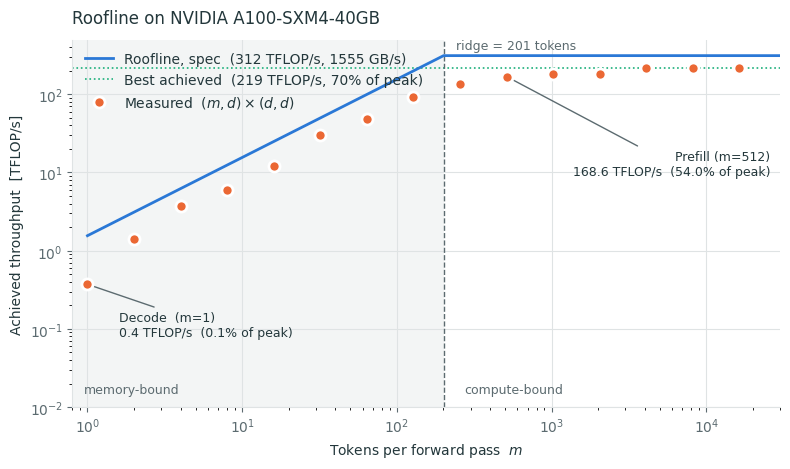

In [5]:
tf_meas = np.array([flops(m) / results[m] / 1e12 for m in MS])


def point(m):
    return m, flops(m) / results[m] / 1e12


plot_roofline(
    MS,
    tf_meas,
    peak_tflops=GPU_PEAK_TFLOPS_OPT,
    bandwidth_tbs=GPU_BW_TBS_OPT,
    achieved_tflops=PEAK_TFLOPS,
    annotations=[
        ("Decode  (m=1)", *point(1)),
        ("Prefill (m=512)", *point(512), (2.6e4, point(512)[1] * 0.055), "right"),
    ],
    device=torch.cuda.get_device_name(0),
)
plt.show()


#### Why do we not meet theoretical maximum throughput?
- Kernel launch overhead (~5%)
- Kernel inefficiency
- We have simplified beforehand: we need to also move activations back and forth, not just weights
- GPU throttling (in my case)

# vLLM

## Why should you use vLLM?
- Much faster than transformers
- Support for multiple advanced inference methods out-of-the-box (parallelism, quantization, pruning, speculative decoding, ...)


#### Key vLLM parameters
- `--gpu-memory-utilization`: How much % of GPU memory vLLM should aim to occupy. Set as high as possible, but might crash if set too high (use 0.8-0.95).
- `--enforce-eager`: Enable/Disable Cuda Graph compilation. Runs faster, but takes longer for startup and might require large cache on disk. Also risks crashing on custom models / when tinkering with vLLM.
- `--enable-prefix-caching`: Caches repeated prefixes and loads them from memory instead of running prefill. Disable for performance measurements
- `--max-model-len`: Maximum context length to serve. Increases GPU memory requirements due to KV caching.
- `--max-num-seqs`: Number of requests vLLM may serve concurrently. Increases batching potential, but each request may take longer to complete and
GPU memory requirements are higher.

We now measure prefill and decode throughput on a real model. We run the *same* prompts twice,
once generating a single token (prefill-dominated) and once prefilling just one token and then generating many tokens, then attribute the
difference to decoding.

#### vLLM Setup

In [6]:
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
REPEATS = 1
# PROMPT_LEN = 4096
# DECODE_TOKENS = 128
PROMPT_LEN = 1024
DECODE_TOKENS = 32

llm = LLM(
    MODEL,
    dtype="bfloat16",
    gpu_memory_utilization=0.8,
    enable_prefix_caching=False,
    max_num_seqs=max(BATCH_SIZES),
    max_model_len=PROMPT_LEN + DECODE_TOKENS,
)

tok = llm.get_tokenizer()

INFO 09-08 15:37:39 [arg_utils.py:813] HF_HUB_OFFLINE is True, replace model_id [Qwen/Qwen3-4B] to model_path [/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c]
INFO 09-08 15:37:40 [api_utils.py:272] non-default args: {'dtype': 'bfloat16', 'max_model_len': 1056, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.8, 'max_num_seqs': 256, 'disable_log_stats': True, 'model': '/lustre/fast/fast/aconzelmann/hf_home/hub/models--Qwen--Qwen3-4B/snapshots/1cfa9a7208912126459214e8b04321603b3df60c'}
WARNING 09-08 15:37:40 [arg_utils.py:1719] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-08 15:37:40 [model.py:672] Resolved architecture: Qwen3ForCausalLM
INFO 09-08 15:37:40 [model.py:1965] Using max model len 1056
INFO 09-08 15:37:40 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 09-08 15:37:49 [weight_utils.py:792] Prefetching checkpoint files: 10% (1/3)
INFO 09-08 15:37:50 [weight_utils.py:792] Prefetching checkpoint files: 20% (2/3)
INFO 09-08 15:37:50 [weight_utils.py:792] Prefetching checkpoint files: 30% (3/3)
INFO 09-08 15:37:50 [weight_utils.py:815] Prefetching checkpoint files into page cache finished in 0.94s


Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:02<00:05,  2.90s/it]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:06<00:03,  3.03s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:06<00:00,  1.80s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:06<00:00,  2.12s/it]


INFO 09-08 15:37:55 [default_loader.py:430] Loading weights took 6.39 seconds


INFO 09-08 15:37:56 [model_runner.py:380] Model loading took 7.56 GiB memory and 10.499272 seconds
INFO 09-08 15:37:56 [topk_topp_sampler.py:46] FlashInfer top-p/top-k sampling disabled via VLLM_USE_FLASHINFER_SAMPLER=0.
INFO 09-08 15:38:09 [backends.py:1094] Using cache directory: /tmp/vllm_cache/torch_compile_cache/dc2d07546d/rank_0_0/backbone for vLLM's torch.compile
INFO 09-08 15:38:09 [backends.py:1155] Dynamo bytecode transform time: 8.15 s
INFO 09-08 15:38:16 [backends.py:393] Compiling a graph for compile range (1, 8192) takes 6.38 s
INFO 09-08 15:38:22 [backends.py:920] collected artifacts: 37 entries, 3 artifacts, 6379817 bytes total
INFO 09-08 15:38:22 [decorators.py:708] saved AOT compiled function to /tmp/vllm_cache/torch_compile_cache/torch_aot_compile/f73149ba22744505642c2f013e4837ea7393c61d525ead5def5c33958153fb44/rank_0_0/model
INFO 09-08 15:38:22 [monitor.py:53] torch.compile took 20.90 s in total
INFO 09-08 15:38:22 [monitor.py:81] Initial profiling/warmup run took 0

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:01<00:00, 22.31it/s]

INFO 09-08 15:38:30 [model_runner.py:906] Graph capturing finished in 5 secs, took 0.56 GiB
INFO 09-08 15:38:30 [gpu_worker.py:804] Free memory on device (39.03/39.49 GiB) on startup. Desired GPU memory utilization is (0.8, 31.59 GiB). Actual usage is 7.8 GiB for consumed memory (weights + non-torch), 0.8 GiB for peak activation, and 0.56 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=23927517082` (22.28 GiB) to fit into requested memory, or `--kv-cache-memory=31907337728` (29.72 GiB) to fully utilize gpu memory. Current kv cache memory in use is 22.99 GiB.


INFO 09-08 15:38:32 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
WARNING 09-08 15:38:32 [torch_utils.py:250] OMP_NUM_THREADS=4 is set; leaving Torch threads at 4 for serving. Multi-threaded torch CPU ops during serving can degrade performance through spin-wait contention and cgroup CPU-quota throttling.
INFO 09-08 15:38:32 [core.py:347] init engine (profile, create kv cache, warmup model) took 36.30 s (compilation: 20.90 s)
INFO 09-08 15:38:33 [hf.py:551] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


In [7]:
! nvidia-smi

Tue Sep  8 15:38:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:C1:00.0 Off |                    0 |
| N/A   33C    P0             61W /  300W |   32877MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Something to keep in mind: As soon as vLLM is booted up, it **will** use `gpu_memory_utilization` % of your GPU memory, even if you don't run anything through it. 

#### Decoding versus Prefill

The cell below sweeps the batch size and plots both. 

 batch   prefill tok/s   decode tok/s  decode/batch
---------------------------------------------------
     1          21,591            123           123
     2          22,737            243           122
     4          24,191            489           122
     8          24,286            957           120
    16          24,594          1,862           116
    32          24,534          3,759           117
    64          24,516          6,824           107
   128          24,442         11,968            94
   256          24,378         16,514            65


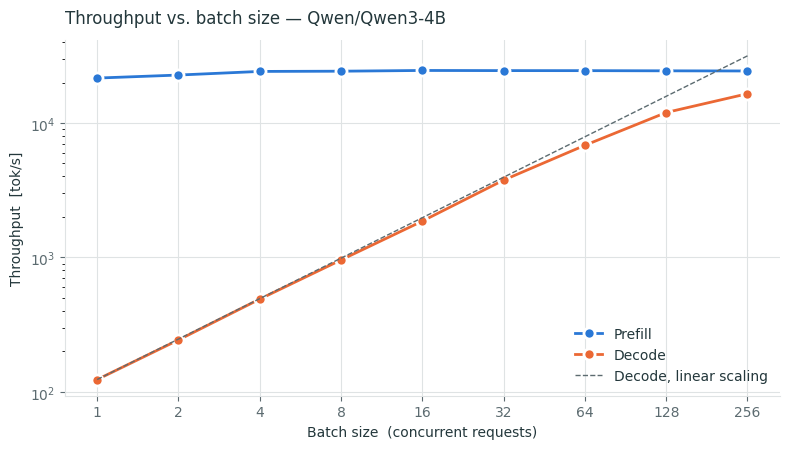

: 

In [ ]:
REPEATS = 1
base = tok.decode(
    tok("The history of machine learning. " * PROMPT_LEN).input_ids[:PROMPT_LEN]
)


def measure(batch):
    """Prefill and decode throughput (tok/s) at a given batch size."""
    prefill = [base] * batch
    decode = ["a"] * batch  # prefill just one token so its decode dominated

    def run(max_tokens, prompt, repeats=REPEATS):
        sp = SamplingParams(temperature=0.0, max_tokens=max_tokens, ignore_eos=True)
        llm.generate(prompt, sp, use_tqdm=False)  # warm-up
        best, n_in, n_out = float("inf"), 0, 0
        for _ in range(repeats):
            t0 = time.perf_counter()
            out = llm.generate(prompt, sp, use_tqdm=False)
            best = min(best, time.perf_counter() - t0)
            n_in = sum(len(o.prompt_token_ids) for o in out)
            n_out = sum(len(o.outputs[0].token_ids) for o in out)
        return best, n_in, n_out

    t_pre, n_in, _ = run(1, prefill)  # prefill-dominated
    t_base, _, _ = run(1, decode)  # same workload, decode steps removed
    t_full, _, n_out = run(DECODE_TOKENS, decode)
    return n_in / t_pre, (n_out - batch) / (t_full - t_base)


print(f"{'batch':>6}{'prefill tok/s':>16}{'decode tok/s':>15}{'decode/batch':>14}")
print("-" * 51)
prefill_tps, decode_tps = [], []
for b in BATCH_SIZES:
    p_tps, d_tps = measure(b)
    prefill_tps.append(p_tps)
    decode_tps.append(d_tps)
    print(f"{b:>6}{p_tps:>16,.0f}{d_tps:>15,.0f}{d_tps / b:>14,.0f}")

plot_scaling(
    BATCH_SIZES,
    {"Prefill": prefill_tps, "Decode": decode_tps},
    ideal_from="Decode",
    xlabel="Batch size  (concurrent requests)",
    ylabel="Throughput  [tok/s]",
    title=f"Throughput vs. batch size — {MODEL}",
)
plt.show()

Prefill throughput barely moves, as it was already compute-bound at one prompt. 
Decode throughput scales close to linearly, because the extra sequences ride along on weight reads we were paying for anyway.

That asymmetry is why the two phases are budgeted separately: prefill cost is measured in
**time-to-first-token (TTFT)**, decode cost in **inter-token latency (ITL)**, and a serving system is tuned
by trading one against the other.